In [9]:
from src.exp import *

healthy_train_cells, test_cells = get_health_divided_train_test(healthy_test_size=0.5)
print(f'{len(healthy_train_cells)} healthy training cells; {len(test_cells)} mixed health test cells\n')

X_train = get_windows(cells=healthy_train_cells, window_size=100, window_skip=50)
print_data_stats(X_train)

Checking attributes: 100%|██████████| 333/333 [00:00<00:00, 4517.34it/s]


52 healthy training cells; 281 mixed health test cells



Getting windows: 100%|██████████| 52/52 [00:00<00:00, 52.14it/s]



===TRAINING DATA STATS===
mean: 	26.613374710083008 
std: 	6.87251091003418 
min: 	0.0
max: 	55.361000061035156
shape:	 (9576544, 100, 1)


In [2]:
from tensorflow import keras 
from src.models import LSTMAutoencoder
import pickle

autoencoder_model = LSTMAutoencoder(training_data=X_train)
autoencoder_model.compile(optimizer='adam', 
                          loss='mse',
                          metrics=[keras.metrics.RootMeanSquaredError(), 'accuracy'])
history = autoencoder_model.fit(X_train, X_train, epochs=3, batch_size=32)

print("Training Loss:", history.history['loss'])
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['root_mean_squared_error'])

# Assuming 'model' is your trained model object
with open(trained_model_name(), 'wb') as file:
    pickle.dump(autoencoder_model, file)

Epoch 1/3
315767/315767 ━━━━━━━━━━━━━━━━━━━━ 85228s 270ms/step - accuracy: 0.0000e+00 - loss: 5.3281 - root_mean_squared_error: 2.3083
Epoch 2/3
315767/315767 ━━━━━━━━━━━━━━━━━━━━ 117391s 372ms/step - accuracy: 0.0000e+00 - loss: 4.1819 - root_mean_squared_error: 2.0450
Epoch 3/3
315767/315767 ━━━━━━━━━━━━━━━━━━━━ 131003s 415ms/step - accuracy: 0.0000e+00 - loss: nan - root_mean_squared_error: nan
Training Loss: [5.328074932098389, 4.181875228881836, nan]
Training Accuracy: [0.0, 0.0, 0.0]
Validation Accuracy: [2.308262348175049, 2.0449633598327637, nan]


3235/3235 ━━━━━━━━━━━━━━━━━━━━ 278s 84ms/step
(103515, 100, 1) (103515, 100, 1)


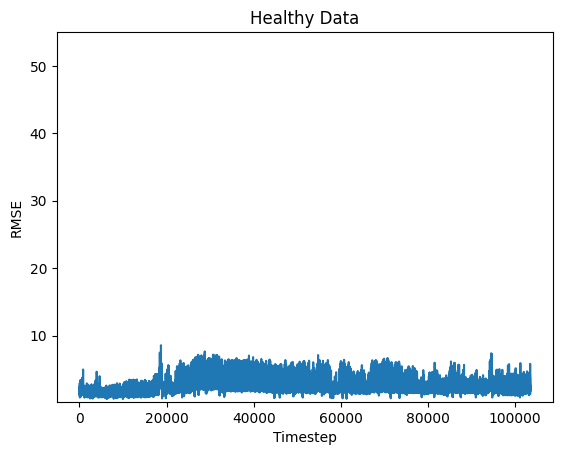

In [4]:
test_cells_healthy = [
    'data/preprocessed/UL-PUR_R15-EX4_18650_NCA_23C_2.5-96.5_0.5-0.5C_d_timeseries.pkl'
]
X_test, _, _ = get_windows(cells=test_cells_healthy, window_size=100)

healthy_predictions = autoencoder_model.predict(X_test)
print(healthy_predictions.shape, X_test.shape)
plot_results(X_test, healthy_predictions, 'Healthy Data')

In [5]:
test_cells_unhealthy = [
    'data/preprocessed/LFP_15Ah_60SOC_cell1_MAX.pkl'
]
X_test_unhealthy, _, _ = get_windows(cells=test_cells_unhealthy, window_size=100)

unhealthy_predictions = autoencoder_model.predict(X_test_unhealthy)
print(unhealthy_predictions.shape, X_test_unhealthy.shape)
plot_results(X_test_unhealthy, unhealthy_predictions, 'Unhealthy Data')

FileNotFoundError: [Errno 2] No such file or directory: 'data/preprocessed/LFP_15Ah_60SOC_cell1_MAX.pkl'

In [2]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print(tf.config.list_physical_devices())

def get_available_devices():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos]

print(get_available_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
['/device:CPU:0']


In [12]:
tf.version.VERSION

'2.20.0'

In [1]:
import sys
print(sys.prefix)

c:\Users\CalcUser\AppData\Local\Programs\Python\Python313
